# FAKE NEWS DETECTION


In [10]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# 1. LOAD DATASET

In [11]:

true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

df = pd.concat([true_df, fake_df])

df = df.sample(frac=1).reset_index(drop=True)

print("Dataset shape:", df.shape)


Dataset shape: (44898, 5)


In [12]:
df.head()

,title,text,subject,date,label
0,WATCH: Van Jones SHUTS DOWN Trump Supporter F...,Trump and his deplorable supporters worked for...,News,"November 10, 2016",0
1,"Trump to meet House, Senate tax cut negotiator...",WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"December 12, 2017",1
2,Trump congratulates China's Xi on 'extraordina...,WASHINGTON (Reuters) - U.S. President Donald T...,worldnews,"October 25, 2017",1
3,McCain Responds With Zero F*cks To Give Over ...,Sen. John McCain (R-Ariz) went full-Maverick d...,News,"October 17, 2017",0
4,Crocodile kills British journalist holidaying ...,COLOMBO (Reuters) - A young British journalist...,worldnews,"September 15, 2017",1


# 2. BASIC DATA ANALYSIS


Checking missing values
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Class distribution
label
0    23481
1    21417
Name: count, dtype: int64


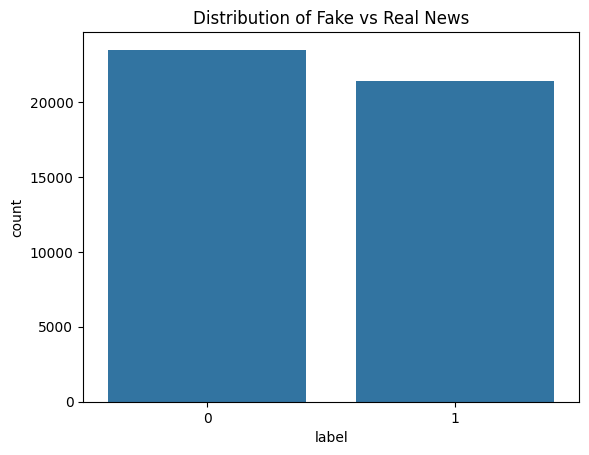

In [13]:
print("\nChecking missing values")

print(df.isnull().sum())

print("\nClass distribution")

print(df["label"].value_counts())

sns.countplot(x=df["label"])
plt.title("Distribution of Fake vs Real News")
plt.show()

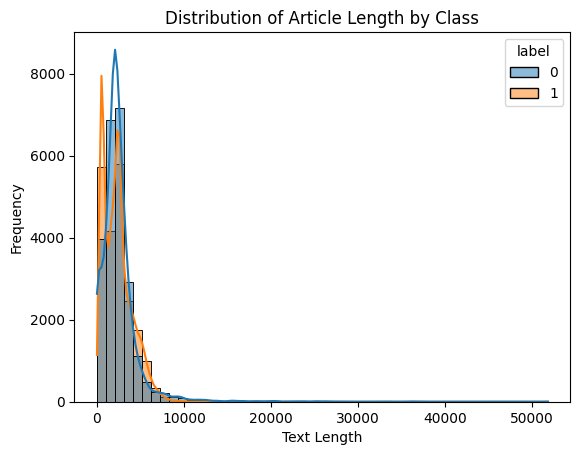

In [14]:

df['text_length'] = df['text'].apply(len)

sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribution of Article Length by Class')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

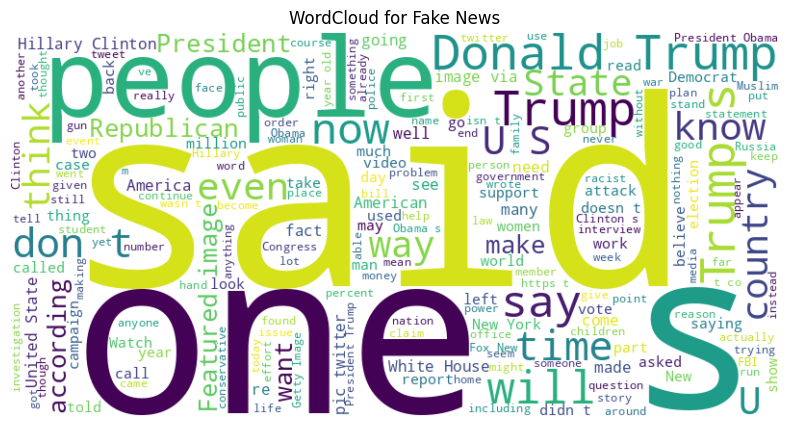

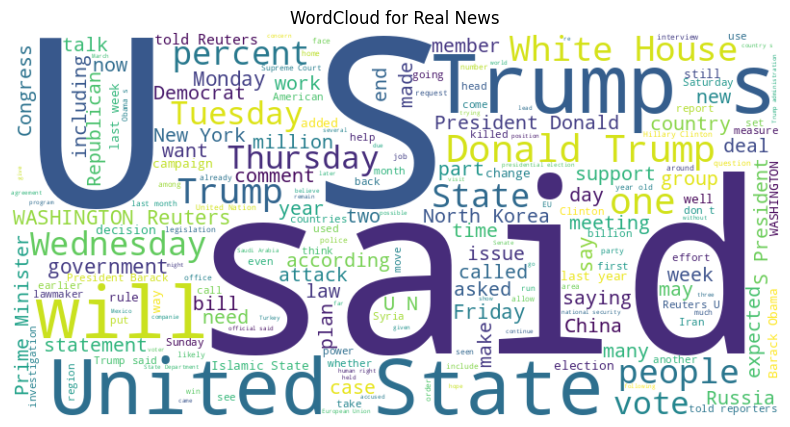

In [15]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud for FAKE news
fake_text = " ".join(df[df['label'] == 0]['text'])

fake_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud for Fake News")
plt.show()
# WordCloud for REAL news
real_text = " ".join(df[df['label'] == 1]['text'])

real_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(10,5))
plt.imshow(real_wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud for Real News")
plt.show()

# 3. COMBINE TEXT

In [16]:
df["content"] = df["title"] + " " + df["text"]

In [17]:
print("\nDownloading stopwords")

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

print("Cleaning text...")

df["content"] = df["content"].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tnmt1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning text...


# 5. TF-IDF FEATURE EXTRACTION

In [18]:
print("\nApplying TF-IDF")

X = df["content"]
y = df["label"]

vectorizer = TfidfVectorizer(max_features=8000)

X = vectorizer.fit_transform(X)

print("Feature matrix shape:", X.shape)


Applying TF-IDF
Feature matrix shape: (44898, 8000)


# 6. TRAIN TEST SPLIT

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. MODEL 1 : NAIVE BAYES

In [20]:
print("\nTraining Naive Bayes")

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("\nNaive Bayes Results")

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print(classification_report(y_test, y_pred_nb))



Training Naive Bayes

Naive Bayes Results
Accuracy: 0.9383073496659243
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4623
           1       0.94      0.93      0.94      4357

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



# 8. MODEL 2 : LOGISTIC REGRESSION

In [21]:
print("\nTraining Logistic Regression")

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("\nLogistic Regression Results")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))



Training Logistic Regression

Logistic Regression Results
Accuracy: 0.9870824053452116
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4623
           1       0.98      0.99      0.99      4357

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# 9. MODEL 3 : RANDOM FOREST

In [22]:
print("\nTraining Random Forest")

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Results")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


Training Random Forest

Random Forest Results
Accuracy: 0.9983296213808464
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4623
           1       1.00      1.00      1.00      4357

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# 10. CONFUSION MATRIX

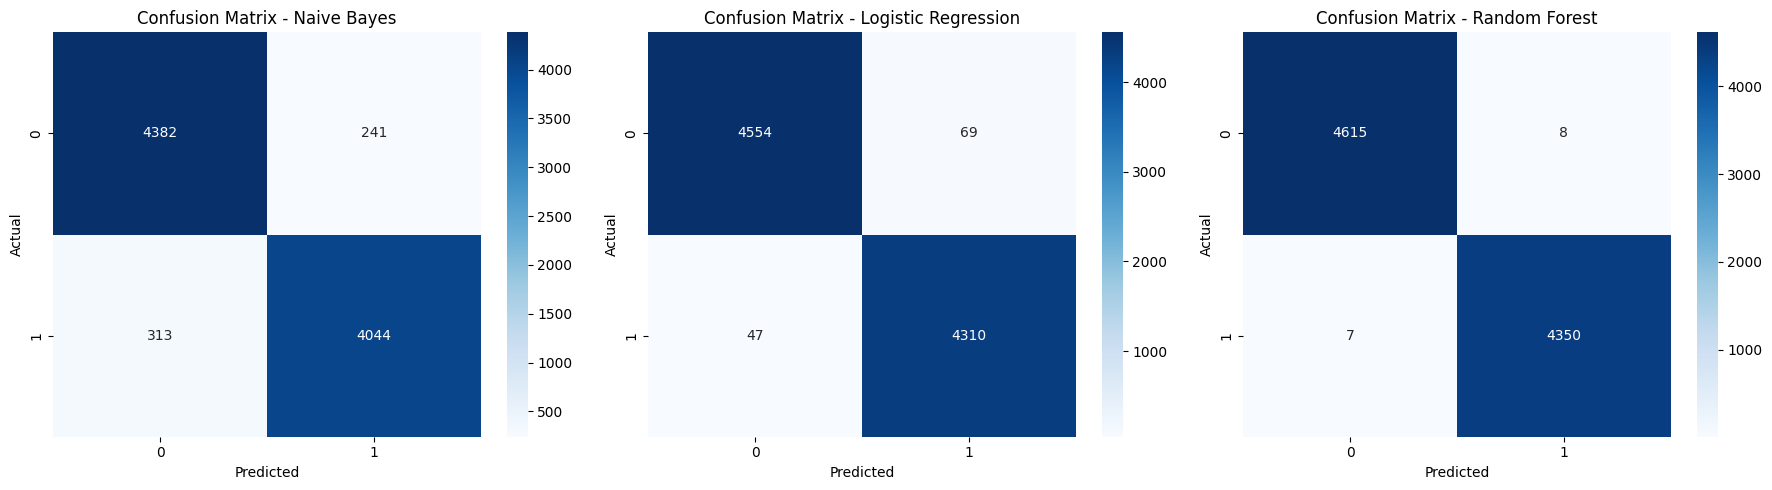

In [23]:

models_preds = [
    ("Naive Bayes", y_pred_nb),
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf)
]

fig, axes = plt.subplots(1, len(models_preds), figsize=(18,5))

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


# 11. MODEL COMPARISON

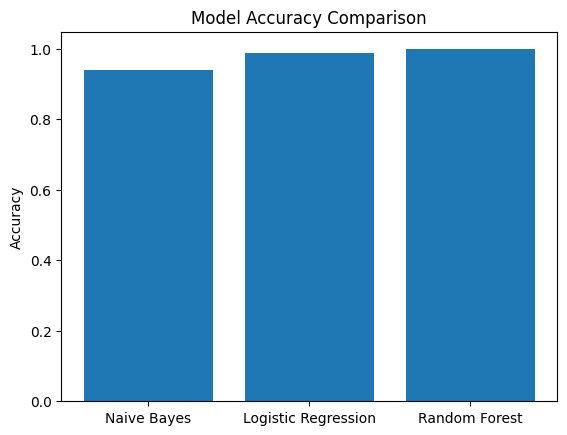

In [24]:
models = ["Naive Bayes","Logistic Regression","Random Forest"]

scores = [
    accuracy_score(y_test,y_pred_nb),
    accuracy_score(y_test,y_pred_lr),
    accuracy_score(y_test,y_pred_rf)
]

plt.bar(models,scores)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()


# 12. BERT Model (Deep Learning)

In [25]:
import torch
from transformers import BertTokenizer,BertForSequenceClassification
from transformers import Trainer,TrainingArguments

### Chuẩn bị dữ liệu

In [ ]:
# Giảm dataset
df_small = df.sample(n=5000, random_state=42)
# tạo content
df["content"] = df["title"] + " " + df["text"]

texts = df["content"].tolist()
labels = df["label"].tolist()

train_texts,test_texts,train_labels,test_labels = train_test_split(
texts,
labels,
test_size=0.2,
random_state=42
)

### Tokenizer

In [27]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts,truncation=True,padding=True,max_length=256)

test_encodings = tokenizer(test_texts,truncation=True,padding=True,max_length=256)

### Dataset

In [28]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self,idx):

        item = {k:torch.tensor(v[idx]) for k,v in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [29]:
train_dataset = NewsDataset(train_encodings,train_labels)

test_dataset = NewsDataset(test_encodings,test_labels)

### Model

In [30]:
import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [31]:
model = BertForSequenceClassification.from_pretrained(
"bert-base-uncased",
num_labels=2
)

c:\Users\tnmt1\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tnmt1\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5371.22it/s]
BertForSequenceClassificatio

# 13. PREDICT NEW NEWS

In [42]:
def predict_news(news):

    news = preprocess(news)

    news_vector = vectorizer.transform([news])

    pred = lr_model.predict(news_vector)

    if pred[0] == 1:
        return "Real News"

    else:
        return "Fake News"

print("\n==============================")
print("TEST NEWS PREDICTION")
print("==============================")

test_news = "President signs new economic policy today"

print("News:", test_news)

print("Prediction:", predict_news(test_news))


TEST NEWS PREDICTION
News: President signs new economic policy today
Prediction: Fake News
